# Stablecoin Depeg Risk Analysis

This notebook fetches stablecoin price data, computes deviation-from-peg metrics, visualizes deviations, and outputs a simple risk summary.


## Notes
- Data source: CoinGecko public API (no key required).
- Deviation is computed relative to a $1.00 peg.
- A "depeg event" is defined as >= 3 consecutive samples with absolute deviation > 1%.
- Risk thresholds are simple heuristics; tune them based on your policy.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

COIN_ID = "usd-coin"  # CoinGecko ids: "tether", "dai", "frax"
VS_CURRENCY = "usd"
DAYS = 90  # number of days of history
CACHE_PATH = DATA_DIR / f"{COIN_ID}_{DAYS}d_{VS_CURRENCY}.csv"


Matplotlib is building the font cache; this may take a moment.


In [2]:
def fetch_price_data(coin_id, vs_currency="usd", days=90, cache_path=None, force_refresh=False):
    cache_path = Path(cache_path) if cache_path else Path(f"data/{coin_id}_{days}d_{vs_currency}.csv")

    if cache_path.exists() and not force_refresh:
        return pd.read_csv(cache_path, parse_dates=["timestamp"])

    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {"vs_currency": vs_currency, "days": days, "interval": "hourly"}
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()

    prices = resp.json().get("prices", [])
    if not prices:
        raise ValueError("No price data returned from CoinGecko.")

    df = pd.DataFrame(prices, columns=["timestamp_ms", "price"])
    df["timestamp"] = pd.to_datetime(df["timestamp_ms"], unit="ms", utc=True)
    df = df.drop(columns=["timestamp_ms"]).sort_values("timestamp")
    df.to_csv(cache_path, index=False)
    return df


df = fetch_price_data(COIN_ID, VS_CURRENCY, DAYS, CACHE_PATH)

df.head()


,price,timestamp
0,0.999416,2025-12-19 03:01:09.162000+00:00
1,0.999901,2025-12-19 04:01:00.574000+00:00
2,0.999924,2025-12-19 05:00:52.024000+00:00
3,0.999896,2025-12-19 06:02:35.979000+00:00
4,1.000061,2025-12-19 07:00:55.050000+00:00


In [3]:
PEG = 1.0

# Deviation metrics
df["deviation"] = df["price"] - PEG
df["deviation_pct"] = df["deviation"] / PEG * 100
df["abs_deviation_pct"] = df["deviation_pct"].abs()

# Depeg events: contiguous runs above 1% deviation
MIN_EVENT_POINTS = 3
mask = df["abs_deviation_pct"] > 1.0
segment_id = (mask != mask.shift()).cumsum()
segment_sizes = df[mask].groupby(segment_id).size()
depeg_events = int((segment_sizes >= MIN_EVENT_POINTS).sum())

summary = {
    "samples": len(df),
    "start": df["timestamp"].min(),
    "end": df["timestamp"].max(),
    "mean_price": df["price"].mean(),
    "std_price": df["price"].std(),
    "max_abs_dev_pct": df["abs_deviation_pct"].max(),
    "p95_abs_dev_pct": df["abs_deviation_pct"].quantile(0.95),
    "time_outside_0_5pct": (df["abs_deviation_pct"] > 0.5).mean(),
    "time_outside_1pct": (df["abs_deviation_pct"] > 1.0).mean(),
    "depeg_events_gt1pct": depeg_events,
}

summary


{'samples': 2162,
 'start': Timestamp('2025-12-19 03:01:09.162000+0000', tz='UTC'),
 'end': Timestamp('2026-03-19 02:42:32+0000', tz='UTC'),
 'mean_price': np.float64(0.999855322465916),
 'std_price': np.float64(0.00017244336671931037),
 'max_abs_dev_pct': np.float64(0.3490397637502918),
 'p95_abs_dev_pct': np.float64(0.03899768138348081),
 'time_outside_0_5pct': np.float64(0.0),
 'time_outside_1pct': np.float64(0.0),
 'depeg_events_gt1pct': 0}

In [4]:
def classify_risk(s):
    if s["max_abs_dev_pct"] >= 5 or s["time_outside_1pct"] >= 0.05:
        return "High"
    if s["max_abs_dev_pct"] >= 2 or s["time_outside_1pct"] >= 0.01:
        return "Medium"
    return "Low"

risk_level = classify_risk(summary)

insights = [
    f"Risk level: {risk_level}",
    f"Window: {summary['start'].date().isoformat()} to {summary['end'].date().isoformat()}",
    f"Max abs deviation: {summary['max_abs_dev_pct']:.2f}%",
    f"95th pct abs deviation: {summary['p95_abs_dev_pct']:.2f}%",
    f"Time outside ±0.5%: {summary['time_outside_0_5pct']:.2%}",
    f"Time outside ±1.0%: {summary['time_outside_1pct']:.2%}",
    f"Depeg events >1% (>= {MIN_EVENT_POINTS} consecutive samples): {summary['depeg_events_gt1pct']}",
]

for line in insights:
    print(line)


Risk level: Low
Window: 2025-12-19 to 2026-03-19
Max abs deviation: 0.35%
95th pct abs deviation: 0.04%
Time outside ±0.5%: 0.00%
Time outside ±1.0%: 0.00%
Depeg events >1% (>= 3 consecutive samples): 0


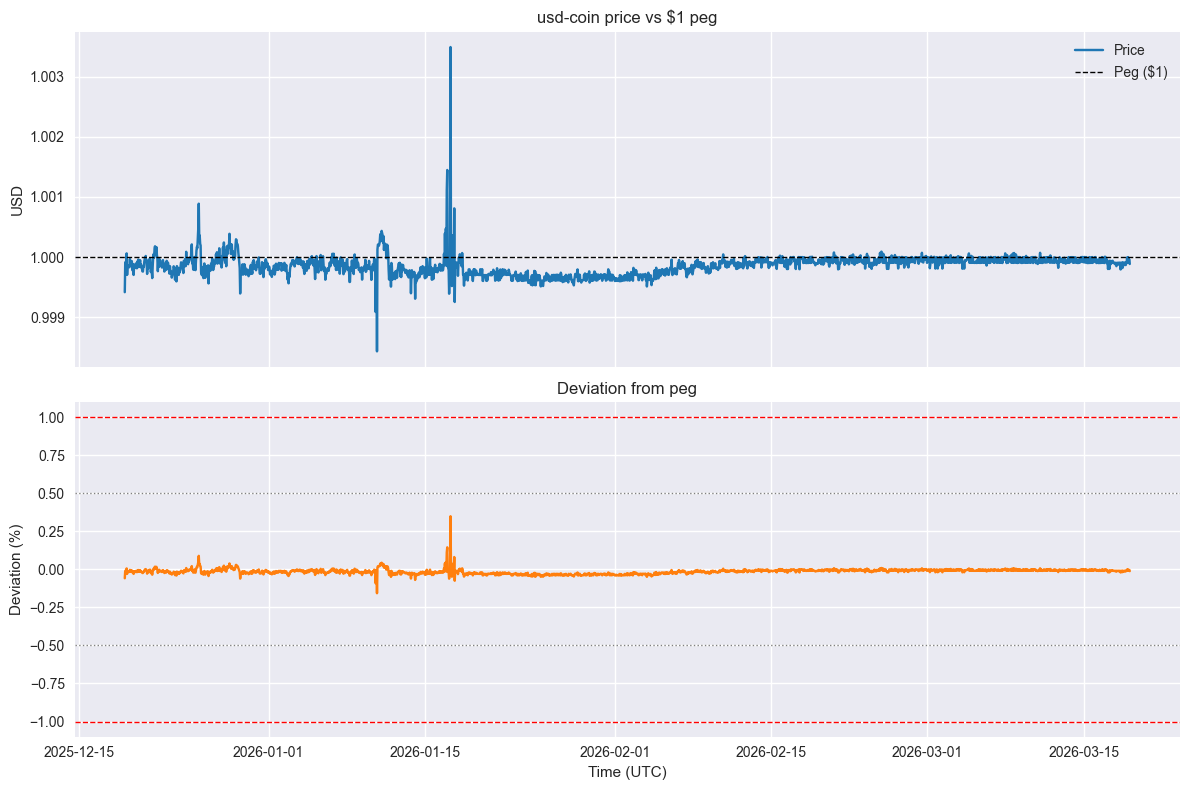

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["timestamp"], df["price"], label="Price", color="tab:blue")
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1, label="Peg ($1)")
axes[0].set_ylabel("USD")
axes[0].set_title(f"{COIN_ID} price vs $1 peg")
axes[0].legend(loc="upper right")

axes[1].plot(df["timestamp"], df["deviation_pct"], color="tab:orange", label="Deviation (%)")
axes[1].axhline(1.0, color="red", linestyle="--", linewidth=1)
axes[1].axhline(-1.0, color="red", linestyle="--", linewidth=1)
axes[1].axhline(0.5, color="gray", linestyle=":", linewidth=1)
axes[1].axhline(-0.5, color="gray", linestyle=":", linewidth=1)
axes[1].set_ylabel("Deviation (%)")
axes[1].set_xlabel("Time (UTC)")
axes[1].set_title("Deviation from peg")

plt.tight_layout()
